In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
import os


# LEITURA DOS DADOS

pontos = np.loadtxt("pontos_uniforme.csv", delimiter=",")
hist = pd.read_csv("evolucao.csv")

# Lê as 3 rotas do arquivo (primeira, meio, melhor)
with open("melhor_rota.txt") as f:
    rotas = [list(map(int, line.strip().split())) for line in f.readlines() if line.strip()]
rota_primeira = rotas[0]
rota_meio = rotas[1]
rota_melhor = rotas[2]

primeira_dist = hist['MelhorDistancia'].iloc[0]
meio_dist = hist['MelhorDistancia'].iloc[len(hist)//2]
melhor_dist = hist['MelhorDistancia'].iloc[-1]


# CÁLCULO DA DISTÂNCIA ÓTIMA (CASO CIRCULAR)
def calcular_distancia_otima(n, raio=100000.0):
    return n * 2 * raio * np.sin(np.pi / n)

n_pontos = len(pontos)
dist_otima = calcular_distancia_otima(n_pontos)
acerto_percentual = melhor_dist/ dist_otima * 100

print(f"Primeira distância: {primeira_dist}")
print(f"Distância do meio: {meio_dist}")
print(f"Melhor distância: {melhor_dist}")
print(f"Acerto em relação à ótima: {acerto_percentual:.4f}%")


Primeira distância: 10227035.0
Distância do meio: 656042.12
Melhor distância: 628190.62
Acerto em relação à ótima: 99.9999%


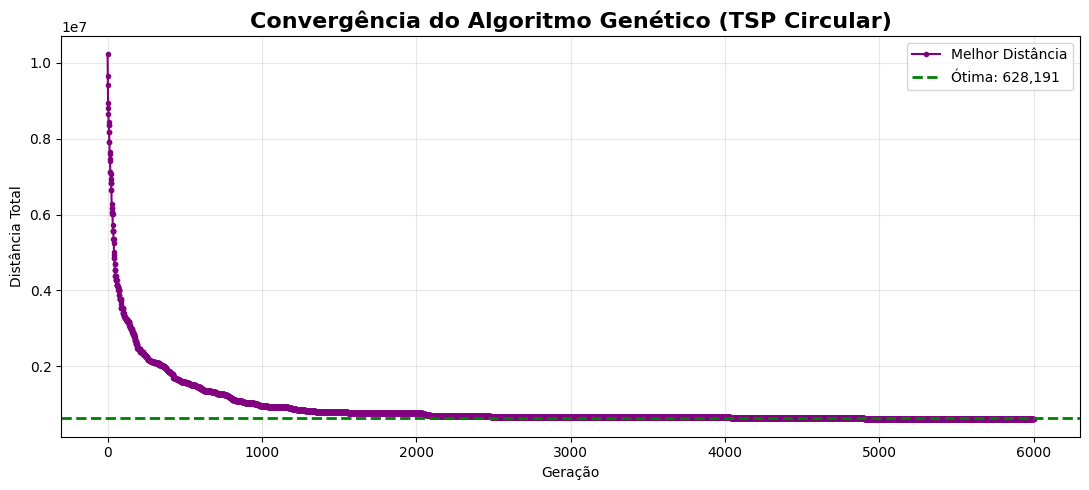

In [134]:
# GRÁFICO DE CONVERGÊNCIA
plt.figure(figsize=(11, 5))
plt.plot(hist['Geracao'], hist['MelhorDistancia'], 'o-', color='purple', markersize=3, label='Melhor Distância')
plt.axhline(y=dist_otima, color='green', linestyle='--', linewidth=2, label=f'Ótima: {dist_otima:,.0f}')
plt.title("Convergência do Algoritmo Genético (TSP Circular)", fontsize=16, fontweight='bold')
plt.xlabel("Geração")
plt.ylabel("Distância Total")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

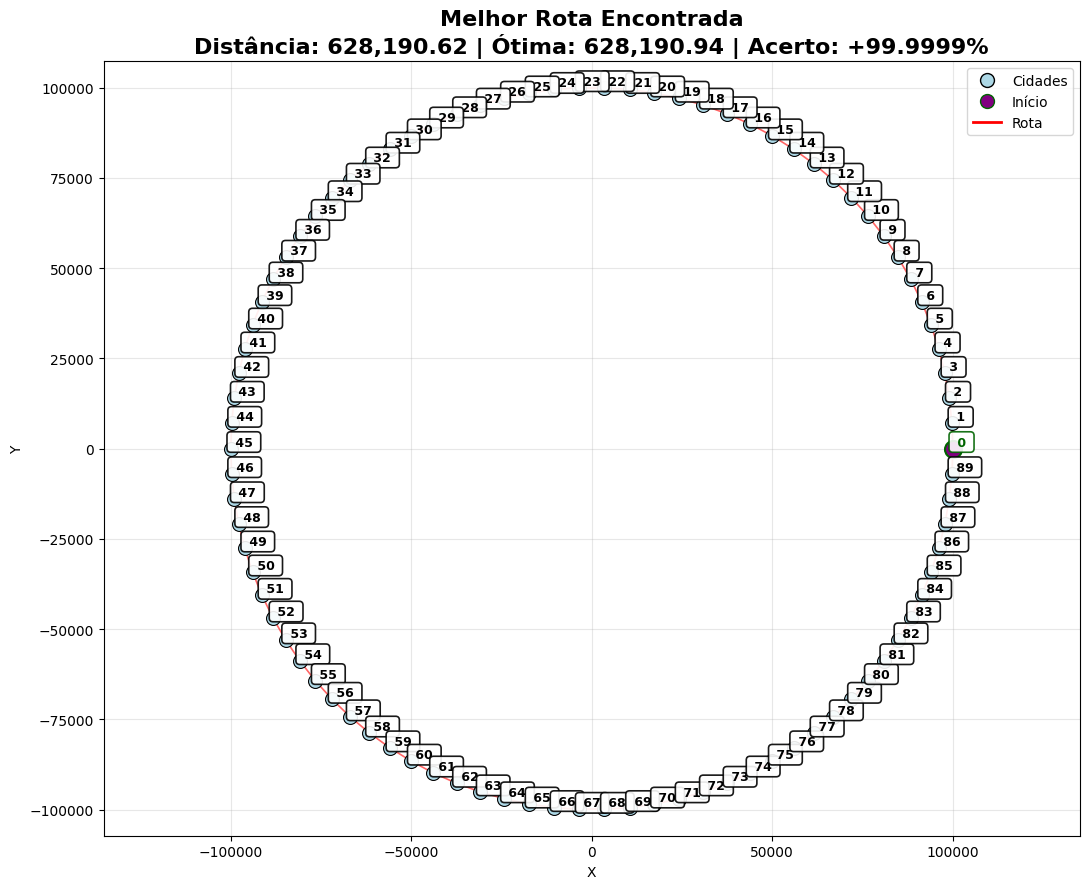

In [135]:
# VISUALIZAÇÃO DA MELHOR ROTA
def plotar_rota(rota, titulo, cor_linha='red', cor_inicio='purple'):
    plt.figure(figsize=(11, 9))
    x, y = pontos[:, 0], pontos[:, 1]
    plt.scatter(x, y, c='lightblue', s=100, zorder=5, edgecolors='black', linewidth=0.8)

    # Marca o ponto inicial
    ini = rota[0]
    plt.scatter(x[ini], y[ini], c=cor_inicio, s=150, zorder=6, edgecolors='darkgreen', linewidth=1.5)

    # Rótulos dos pontos
    for i, (xi, yi) in enumerate(pontos):
        offset = 0.3
        color = 'darkgreen' if i == ini else 'black'
        plt.text(xi + offset, yi + offset, f' {i} ', fontsize=9, fontweight='bold', color=color,
                 ha='left', va='bottom',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9, edgecolor=color, linewidth=1.2),
                 zorder=7)

    # Desenha arestas com setas
    for i in range(len(rota)):
        i1, i2 = rota[i], rota[(i + 1) % len(rota)]
        p1, p2 = pontos[i1], pontos[i2]
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color=cor_linha, lw=1.2, alpha=0.6, zorder=3)

    # Legenda personalizada
    legend = [
        Line2D([0],[0], marker='o', color='w', label='Cidades', markerfacecolor='lightblue', markersize=10, markeredgecolor='black'),
        Line2D([0],[0], marker='o', color='w', label='Início', markerfacecolor=cor_inicio, markersize=10, markeredgecolor='darkgreen'),
        Line2D([0],[0], color=cor_linha, lw=2, label='Rota')
    ]
    plt.legend(handles=legend, loc='upper right', fontsize=10)

    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.xlabel('X'); plt.ylabel('Y')
    plt.axis('equal')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot da melhor rota
dist_str = f"{melhor_dist:,.2f}"
otima_str = f"{dist_otima:,.2f}"
erro_str = f"{acerto_percentual:+.4f}%"
titulo = f"Melhor Rota Encontrada\nDistância: {dist_str} | Ótima: {otima_str} | Acerto: {erro_str}"
plotar_rota(rota_melhor, titulo, cor_linha='red', cor_inicio='purple')

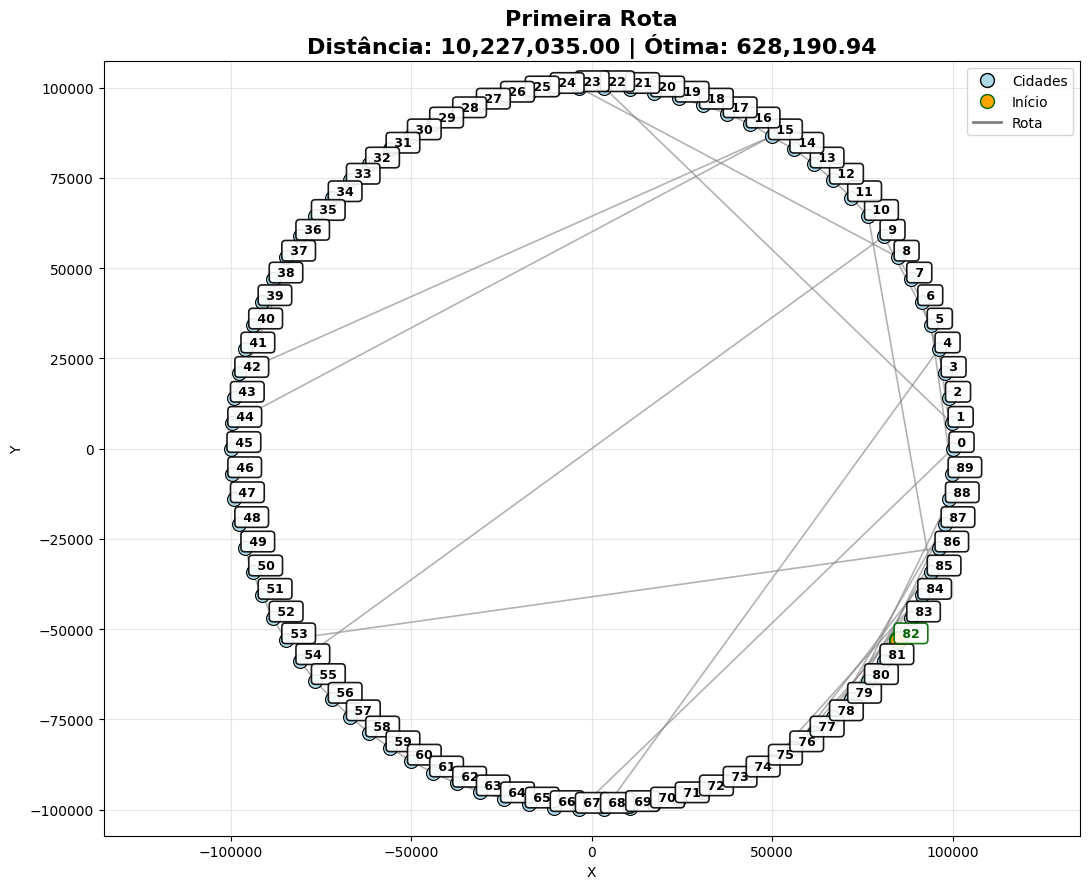

In [136]:
# VISUALIZAÇÃO DA PRIMEIRA ROTA
titulop =(f"Primeira Rota\n"
    f"Distância: {primeira_dist:,.2f} | Ótima: {dist_otima:,.2f}"
)
plotar_rota(rota_primeira, titulop, cor_linha='gray', cor_inicio='orange')

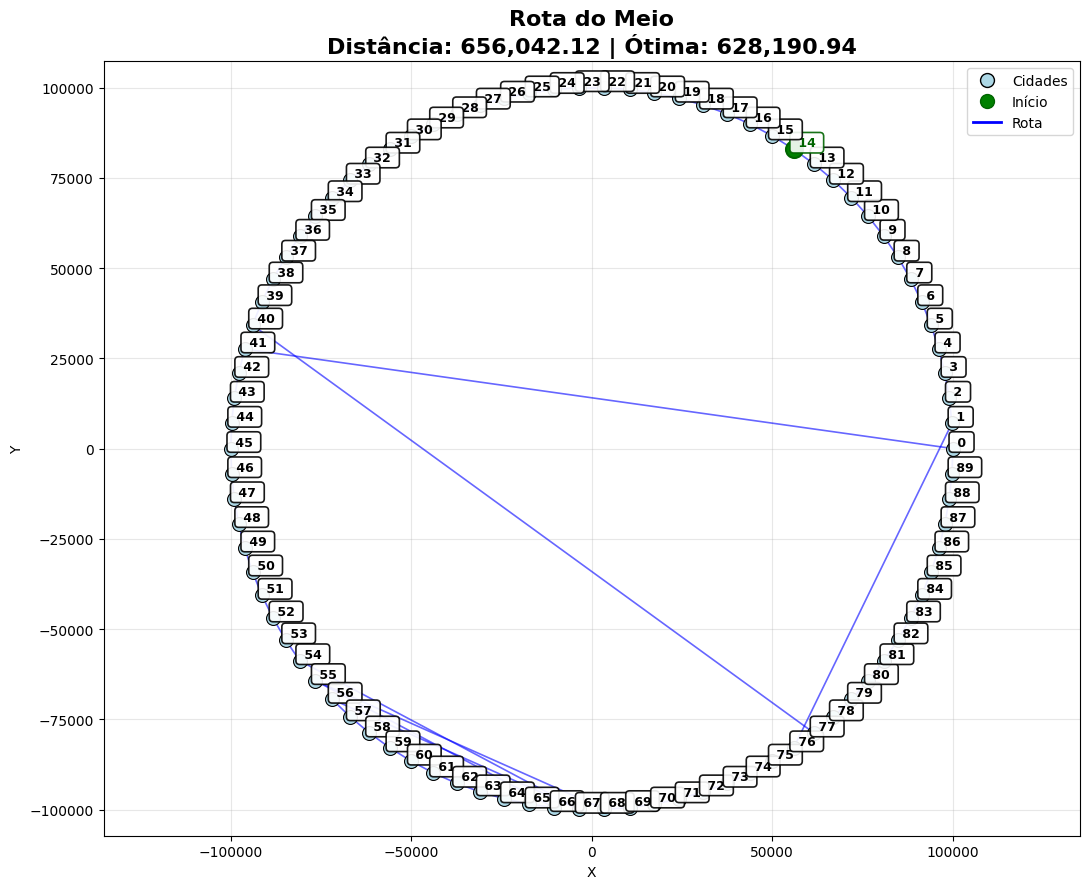

In [137]:
# VISUALIZAÇÃO DA ROTA DO MEIO
titulom = (
    f"Rota do Meio\n"
    f"Distância: {meio_dist:,.2f} | Ótima: {dist_otima:,.2f}"
)
plotar_rota(rota_meio, titulom, cor_linha='blue', cor_inicio='green')